<a href="https://colab.research.google.com/github/zcflanzer/rcew-water-budget/blob/main/OpenET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenET data
Author: Zoe Flanzer\
Last updated: 5/15/2026\
Purpose: To download OpenET in designated area and save data to drive.

In [ ]:
## setting up notebook
# importing important libraries
!pip install pycrs
!pip install wxee
import geopandas as gpd
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import geemap
import google.colab
import geemap as emap
import ee
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

# initializing and authenticating GEE
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project = 'ee-zoeflanzer') # change GEE project name

In [ ]:
## importing site shapefile
# reading file
shp_file = gpd.read_file('/content/drive/MyDrive/Thesis/Data/Shapefiles/aspect/3.shp')

# setting crs
if shp_file.crs is None:
   shp_file.crs = 'EPSG:26911'
shp_file = shp_file.to_crs('EPSG:4326') # reprojecting to correspond to OpenET

# converting shapefile to GEE feature
fc = geemap.geopandas_to_ee(shp_file)

In [ ]:
## defining dates of analysis
# for single year:
start_date = '2015-10-01' # start of year
end_date = '2016-09-30' # end of year

# for multi-year:
start_yr = 2000 # start of loop
end_yr = 2025 # end of loop + 1 year

In [ ]:
# defining function to get water year dates
def wy_dates(year):
  start_date = f'{year-1}-10-01'
  end_date = f'{year}-09-30'
  return start_date, end_date

## Annual data

**Testing one year of data**

In [ ]:
## downloading all data for the year
# importing OpenET data within study site
ET_data= ee.ImageCollection("OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc).select('et_ensemble_mad').sum() # enemble MAD data, mm

# checking that OpenET projection corresponds to converted shapefile projection
ET_projection = ET_data.projection()
ET_projection_info = ET_projection.getInfo()
EPSG_code = ET_projection_info['crs']
print(EPSG_code)

In [ ]:
## calculating 1 year of annual ET and mapping
# calculating annual average values
Et_data_mm = ET_data.reduceRegion(reducer = ee.Reducer.mean(),geometry = fc.geometry().transform(ET_projection),scale = 30,crs=ET_projection) # watershed mean
annual_ET_OpenET = Et_data_mm.get('et_ensemble_mad').getInfo() / 10 # converting from mm to cm
print(f'Annual ET depth: {annual_ET_OpenET} cm') # printing annual ET depth

## defining center point to center map around
center_pt = shp_file.centroid.iloc[0]
map_center = [center_pt.y, center_pt.x]

# creating map
Map = geemap.Map(center=map_center, zoom=11.5, height='500px')
Map.addLayer(fc, {'color': 'black'}, 'Tollgate Watershed') # adding study site boundary
vis_params = { # defining colors used to represent ET
    'min': 0,
    'max': 1000,
    'palette':['#d9f0d3', '#a6dba0', '#5aae61', '#1b7837'],
    'bands':['et_ensemble_mad']
}
ET_data_vis = ET_data.clip(fc).visualize(**vis_params) # adding ET layer
Map.addLayer(ET_data_vis, {}, 'ET Data')

# displaying map
Map

**Looping through multiple years of data**

In [ ]:
# looping through data to get annual values for designated years
annual_ET_values = [] # initializing storage variable

# loop through years
for year in range(start_yr, end_yr): # change years here
  start_date, end_date = wy_dates(year)

  # importing ET data for each year
  ET_data= ee.ImageCollection("OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0").filter(ee.Filter.date(start_date, end_date)).filterBounds(fc).select('et_ensemble_mad').sum() # ensemble MAD data, mm

  ET_projection = ET_data.projection() # getting projection of ET data

  # calculating annual values
  ET_data_mm = ET_data.reduceRegion(reducer = ee.Reducer.mean(), geometry = fc.geometry().transform(ET_projection), scale = 30, crs=ET_projection)
  annual_ET_OpenET = ET_data_mm.get('et_ensemble_mad').getInfo() / 10 # converting from mm to cm

  # appending values
  annual_ET_values.append([year, annual_ET_OpenET])

In [ ]:
## plotting annual ET values to visualize data
ET_df = pd.DataFrame(annual_ET_values, columns=['Year', 'Annual ET Depth (cm)']) # making data frame of ET depths
plt.figure(figsize=(10, 5))
plt.plot(ET_df['Year'], ET_df['Annual ET Depth (cm)'], marker='o', linestyle='-', color='olive')
slope, intercept = np.polyfit(ET_df['Year'], ET_df['Annual ET Depth (cm)'], 1) # fitting linear line
plt.plot(ET_df['Year'], slope * ET_df['Year'] + intercept, 'r', label='Linear Fit', color = 'darkkhaki', linestyle = '--') # plotting linear slope
plt.xlabel('Year')
plt.ylabel('Annual ET Depth (cm)')
plt.title('West Area Annual ET') # change title
plt.legend()
plt.show()

# print data frame with annual values
print(f'Linear slope: {slope} cm/year')
print(ET_df)

In [ ]:
## testing if ET values are changing over time
# pearson correlation coefficient and p-value
pearson_correlation, p_value = pearsonr(ET_df['Year'], ET_df['Annual ET Depth (cm)'])
print(f'pearson correlation coefficient: {pearson_correlation}, p-value: {p_value}')

# spearman correlation coefficient and p-value
spearman_correlation, p_value = spearmanr(ET_df['Year'], ET_df['Annual ET Depth (cm)'])
print(f'spearman correlation coefficient: {spearman_correlation}, p-value: {p_value}')

In [ ]:
# saving data to csv
#df_yrly = pd.DataFrame({'et_yr': ET_df['Year'], 'et_cm': ET_df['Annual ET Depth (cm)']})
#df_yrly.to_csv('/content/drive/MyDrive/Thesis/Data/ET/south_annual_ET.csv') # change path and name

## Monthly data

In [ ]:
## looping through and calculating monthly values for defined years
monthly_ET_values = []  # initialize storage

# loop through each water year
for year in range(start_yr, end_yr):
    start_date, end_date = wy_dates(year)

    # generate list of monthly start dates within the water year
    current_date = ee.Date(start_date)
    while current_date.millis().lt(ee.Date(end_date).millis()).getInfo():
        next_month = current_date.advance(1, 'month')

        # filter monthly ET data
        ET_month = ee.ImageCollection("OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0").filterDate(current_date, next_month).filterBounds(fc).select('et_ensemble_mad').mean()  # ensemble mean for the month

        ET_projection = ET_month.projection() # getting projection

        # reduce region to get mean ET value
        ET_month_mm = ET_month.reduceRegion(reducer=ee.Reducer.mean(),geometry=fc.geometry().transform(ET_projection),scale=30,crs=ET_projection)

        monthly_ET_cm = ET_month_mm.get('et_ensemble_mad').getInfo() / 10  # converting mm to cm

        # storing data
        month_str = current_date.format('YYYY-MM').getInfo()
        monthly_ET_values.append([month_str, monthly_ET_cm])

        current_date = next_month  # advance to next month

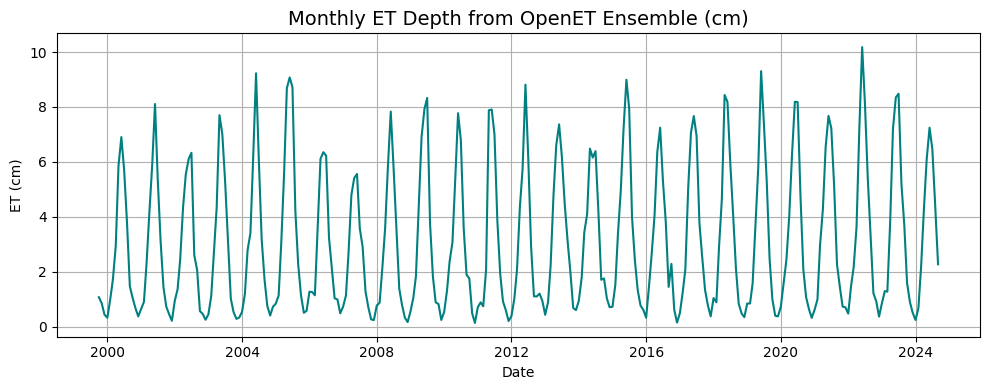

In [ ]:
## saving monthly data in data fram and plotting
df_monthly = pd.DataFrame(monthly_ET_values, columns=['date', 'ET_cm'])

# convert 'date' column to datetime format
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
# df_monthly = df_monthly.sort_values('date') # sort by date if needed

# extract year and month
df_monthly['year'] = df_monthly['date'].dt.year
df_monthly['month'] = df_monthly['date'].dt.month

# plotting
plt.figure(figsize=(10, 4))
plt.plot(df_monthly['date'], df_monthly['ET_cm'], linestyle='-', color='teal')
plt.title('Monthly ET Depth from OpenET Ensemble (cm)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('ET (cm)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# saving data to csv
#df_monthly.to_csv('/content/drive/MyDrive/Thesis/Data/ET/monthly_ET.csv')

## Plotting each OpenET model for comparison (annual)

In [ ]:
## looping through all OpenET models for designated years
# defining dictionary of OpenET datasets
model_datasets = {
    'PTJPL': 'OpenET/PTJPL/CONUS/GRIDMET/MONTHLY/v2_0',
    'SSEBop': 'OpenET/SSEBOP/CONUS/GRIDMET/MONTHLY/v2_0',
    'SIMS': 'OpenET/SIMS/CONUS/GRIDMET/MONTHLY/v2_0',
    'DisALEXI': 'OpenET/DISALEXI/CONUS/GRIDMET/MONTHLY/v2_0',
    'eeMETRIC': 'OpenET/EEMETRIC/CONUS/GRIDMET/MONTHLY/v2_0',
    'geeSEBAL': 'OpenET/GEESEBAL/CONUS/GRIDMET/MONTHLY/v2_0',
    'Ensemble': 'OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0'
}

# initialize storage
results = {year: {} for year in range(start_yr, end_yr)}

# loop through years and models
for year in range(start_yr, end_yr):
    start_date, end_date = wy_dates(year)
    for model, dataset in model_datasets.items():
        band_name = 'et_ensemble_mad' if model == 'Ensemble' else 'et' # calling for 'et' variable for individual models and 'et_ensemble_mad' for just ensemble

        ET_collection = (ee.ImageCollection(dataset).filter(ee.Filter.date(start_date, end_date)).filterBounds(fc).select(band_name))

        # skip if no images
        if ET_collection.size().getInfo() == 0:
            results[year][model] = np.nan
            continue

        ET_data = ET_collection.sum()

        # skip if no bands
        if ET_data.bandNames().size().getInfo() == 0:
            results[year][model] = np.nan
            continue

        ET_projection = ET_data.projection()
        ET_data_mm = ET_data.reduceRegion(reducer=ee.Reducer.mean(),geometry=fc.geometry().transform(ET_projection),scale=30,crs=ET_projection) # watershed mean

        annual_ET = ET_data_mm.get(band_name).getInfo()
        results[year][model] = annual_ET/10 if annual_ET else np.nan  # converting from mm to cm

# convert to data frame
ET_df = pd.DataFrame.from_dict(results, orient='index')
ET_df.index.name = 'Year'

# printing table of values
print(ET_df)

# save to CSV
#ET_df.to_csv("Annual_ET_AllModels.csv")

          PTJPL     SSEBop       SIMS   DisALEXI   eeMETRIC   geeSEBAL  \
Year                                                                     
2000  45.297125  29.325068  37.085714        NaN  26.621660  24.739094   
2001  48.134902  29.944687  41.728571  28.253037  30.685003  28.588135   
2002  44.755448  30.450683  40.685714  28.037278  25.568802  36.812150   
2003  52.676676  30.900421  41.761905  29.533780  28.317878  34.988568   
2004  49.602751  31.243252  33.538095  29.525143  35.315466  33.784359   
2005  59.123555  34.335494  47.671429  41.723196  44.942989  43.695483   
2006  47.758212  28.863658  43.533333  33.346497  31.348390  24.863964   
2007  48.857793  27.955183  39.728745  24.673893  24.471663  34.061132   
2008  44.499426  30.378910   7.895144  26.830180  28.324812  26.914171   
2009  51.088590  31.329637  49.195318  33.523566  38.376081  34.488917   
2010  44.796901  32.041151  35.260937  28.127256  33.850892  29.032167   
2011  51.409717  31.479684   9.081688 

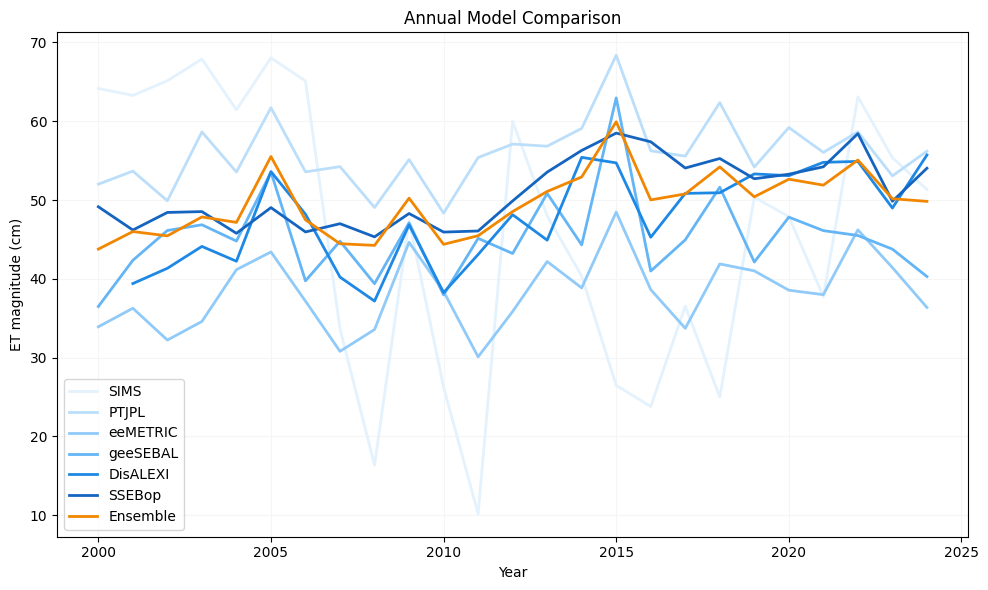

In [ ]:
## plotting model comparison
# importing csv of all model data saved above
df = pd.read_csv('/content/drive/MyDrive/Thesis/Data/ET/Annual_ET_AllModels.csv')

# plotting models by year
plt.figure(figsize=(10,6))
colors = ['#E3F2FD','#BBDEFB','#90CAF9','#64B5F6','#1E88E5','#1565C0','#F18701'] # dictionary of colors to call from
for col, color in zip(['SIMS','PTJPL','eeMETRIC','geeSEBAL','DisALEXI','SSEBop','Ensemble'], colors):
    plt.plot(df['Year'], df[col], color=color, label=col, lw=2)
plt.xlabel('Year')
plt.ylabel('ET magnitude (cm)')
plt.title('Annual Model Comparison')
plt.legend()
plt.grid(True, color='whitesmoke')
plt.tight_layout()
plt.show()